In [24]:
# Decision Tree Model and Business Interpretation Based on a Business Plan

In [25]:
# Task 1: Understand the Business Problem

print("""
Task 1: Understand the Business Problem

1. What is the business about?
NovaMart Retail is a mid-sized retail company that sells everyday products through physical stores and an online channel. The company carries products across apparel, home goods, electronics accessories, beauty, fitness, kitchenware, pet supplies, and office supplies.
The business wants to improve inventory decisions by predicting whether a product should be reordered soon. The goal is to reduce stockouts while also avoiding unnecessary overstock.

2. What problem is the business trying to solve?
NovaMart faces two major inventory problems. The first is stockouts, where products run out before the next supplier delivery arrives, leading to lost sales, lower customer satisfaction, and weaker customer loyalty. The second is overstock, where the business orders too much inventory, which increases storage costs, ties up cash, and may result in markdowns or waste.
NovaMart needs a simple and explainable decision-support model that helps inventory managers identify which products are likely to need a reorder in the near future before a stockout actually happens.

3. What decision can machine learning help the business make?
Machine learning can help NovaMart automatically classify each product into one of two categories: Reorder_Needed = Yes or Reorder_Needed = No. Instead of manually checking hundreds of products, managers can use the model to quickly identify which products need attention. A Decision Tree is especially useful here because it produces simple, readable rules that non-technical business users can understand and trust, such as "if current stock is below 20 units and lead time is more than 10 days, predict Reorder = Yes."

4. What is the target variable in the dataset?
The target variable is Reorder_Needed. It is a binary variable with two possible values: Yes, meaning the product should be reordered soon, and No, meaning the product does not need reordering at this time. This is the variable the Decision Tree model is trained to predict.

5. What are the input features?
The input features are Product_Category, Store_Location, Store_Type, Supplier_Region, Season, Current_Stock_Units, Average_Weekly_Sales, Lead_Time_Days, Unit_Cost, Selling_Price, Discount_Rate, Customer_Rating, Return_Rate, Website_Views, Previous_Stockout, and Competitor_Price_Index.

6. Why is this prediction useful for the business?
This prediction is useful to NovaMart for several reasons. It helps prevent lost sales by allowing managers to reorder products before they run out, keeping shelves stocked and customers satisfied. It reduces overstock costs by only flagging products that genuinely need reordering, which frees up storage space and cash flow. It also saves manager time because instead of reviewing every product manually, managers can focus on the products the model flags as high priority.
The model supports more consistent and data-driven decisions, reducing the chance of human error. Since a Decision Tree produces simple rule-based logic, managers can easily understand and explain the recommendations to stakeholders. Overall, better inventory decisions directly improve sales performance, customer experience, and profitability for NovaMart.
""")


Task 1: Understand the Business Problem

1. What is the business about?
NovaMart Retail is a mid-sized retail company that sells everyday products through physical stores and an online channel. The company carries products across apparel, home goods, electronics accessories, beauty, fitness, kitchenware, pet supplies, and office supplies.
The business wants to improve inventory decisions by predicting whether a product should be reordered soon. The goal is to reduce stockouts while also avoiding unnecessary overstock.

2. What problem is the business trying to solve?
NovaMart faces two major inventory problems. The first is stockouts, where products run out before the next supplier delivery arrives, leading to lost sales, lower customer satisfaction, and weaker customer loyalty. The second is overstock, where the business orders too much inventory, which increases storage costs, ties up cash, and may result in markdowns or waste.
NovaMart needs a simple and explainable decision-suppor

In [5]:
# Task 2: Prepare the Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_excel("C:\\Users\\nnish\\OneDrive\\Desktop\\Dataset\\novamart_inventory_reorder_dataset\\novamart_inventory_reorder_dataset.xlsx")
print("Dataset Loaded Successfully")

# Inspect the dataset
print("\nFirst 5 Rows:")
print(df.head())

# Check the number of rows and columns
print("\nShape of Dataset:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())
print(f"Total Missing Values: {df.isnull().sum().sum()}")

# Check duplicate rows
print("\nDuplicate Rows:")
print(f"Number of Duplicate Rows: {df.duplicated().sum()}")

# Clean the dataset
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()
print(f"\nShape after Removing Duplicates: {df_clean.shape}")

# Fill missing numerical values with median
for col in df_clean.select_dtypes(include=['float64', 'int64']).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing categorical values with mode
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f"Total Missing Values after Cleaning: {df_clean.isnull().sum().sum()}")

# Separate features and target variable
df_clean = df_clean.drop(columns=['Product_ID'])
X = df_clean.drop(columns=['Reorder_Needed'])
y = df_clean['Reorder_Needed']

print(f"\nFeatures Shape: {X.shape}")
print(f"Target Shape: {y.shape}")
print("\nTarget Value Counts:")
print(y.value_counts())

# Handle categorical variables
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print(f"\nTarget Classes: {le_target.classes_}")
print("Encoded Values: 0 = No, 1 = Yes")

X_encoded = X.copy()
label_encoders = {}

for col in X_encoded.select_dtypes(include='object').columns:
    enc = LabelEncoder()
    X_encoded[col] = enc.fit_transform(X_encoded[col])
    label_encoders[col] = enc

print("\nEncoded Features Sample:")
print(X_encoded.head())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining Set Shape: {X_train.shape}")
print(f"Testing Set Shape: {X_test.shape}")

In [6]:
# Load the dataset
df = pd.read_excel("C:\\Users\\nnish\\OneDrive\\Desktop\\Dataset\\novamart_inventory_reorder_dataset\\novamart_inventory_reorder_dataset.xlsx")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [7]:
# Inspect the dataset
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
  Product_ID Product_Category Store_Location Store_Type Supplier_Region  \
0      P0001          Fitness       Downtown   Standard           Local   
1      P0002      Kitchenware       Suburban   Flagship   International   
2      P0003      Kitchenware       Downtown   Standard           Local   
3      P0004          Fitness           Mall   Standard   International   
4      P0005           Beauty       Suburban   Standard   International   

           Season  Current_Stock_Units  Average_Weekly_Sales  Lead_Time_Days  \
0  Back-to-School                   31                    32               2   
1            Fall                    0                    25              16   
2          Spring                   60                    35               5   
3  Back-to-School                  111                    51              16   
4            Fall                  521                    45              23   

   Unit_Cost  Selling_Price  Discount_Rate  Customer_

In [8]:
# Check the number of rows and columns
print("\nShape of Dataset:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Shape of Dataset:
Rows: 365, Columns: 18


In [9]:
# Check data types
print("\nData Types:")
print(df.dtypes)


Data Types:
Product_ID                 object
Product_Category           object
Store_Location             object
Store_Type                 object
Supplier_Region            object
Season                     object
Current_Stock_Units         int64
Average_Weekly_Sales        int64
Lead_Time_Days              int64
Unit_Cost                 float64
Selling_Price             float64
Discount_Rate             float64
Customer_Rating           float64
Return_Rate               float64
Website_Views               int64
Previous_Stockout          object
Competitor_Price_Index    float64
Reorder_Needed             object
dtype: object


In [10]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())
print(f"Total Missing Values: {df.isnull().sum().sum()}")



Missing Values:
Product_ID                 0
Product_Category           0
Store_Location             0
Store_Type                 0
Supplier_Region            8
Season                     0
Current_Stock_Units        0
Average_Weekly_Sales       0
Lead_Time_Days             0
Unit_Cost                  0
Selling_Price              0
Discount_Rate              6
Customer_Rating           10
Return_Rate                7
Website_Views              0
Previous_Stockout          0
Competitor_Price_Index     0
Reorder_Needed             0
dtype: int64
Total Missing Values: 31


In [11]:
# Check duplicate rows
print("\nDuplicate Rows:")
print(f"Number of Duplicate Rows: {df.duplicated().sum()}")


Duplicate Rows:
Number of Duplicate Rows: 5


In [12]:
# Clean the dataset if needed
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()
print(f"\nShape after Removing Duplicates: {df_clean.shape}")

# Fill missing numerical values with median
for col in df_clean.select_dtypes(include=['float64', 'int64']).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing categorical values with mode
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f"Total Missing Values after Cleaning: {df_clean.isnull().sum().sum()}")


Shape after Removing Duplicates: (360, 18)
Total Missing Values after Cleaning: 0


In [13]:
# Separate features and target variable
df_clean = df_clean.drop(columns=['Product_ID'])

X = df_clean.drop(columns=['Reorder_Needed'])
y = df_clean['Reorder_Needed']

print(f"\nFeatures Shape: {X.shape}")
print(f"Target Shape: {y.shape}")
print("\nTarget Value Counts:")
print(y.value_counts())


Features Shape: (360, 16)
Target Shape: (360,)

Target Value Counts:
Reorder_Needed
No     248
Yes    112
Name: count, dtype: int64


In [14]:
# Handle categorical variables
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print(f"\nTarget Classes: {le_target.classes_}")
print("Encoded Values: 0 = No, 1 = Yes")

X_encoded = X.copy()
label_encoders = {}

for col in X_encoded.select_dtypes(include='object').columns:
    enc = LabelEncoder()
    X_encoded[col] = enc.fit_transform(X_encoded[col])
    label_encoders[col] = enc

print("\nEncoded Features Sample:")
print(X_encoded.head())


Target Classes: ['No' 'Yes']
Encoded Values: 0 = No, 1 = Yes

Encoded Features Sample:
   Product_Category  Store_Location  Store_Type  Supplier_Region  Season  \
0                 3               1           3                1       0   
1                 5               4           0                0       1   
2                 5               1           3                1       3   
3                 3               2           3                0       0   
4                 1               4           3                0       1   

   Current_Stock_Units  Average_Weekly_Sales  Lead_Time_Days  Unit_Cost  \
0                   31                    32               2      10.61   
1                    0                    25              16      68.41   
2                   60                    35               5      25.13   
3                  111                    51              16      27.97   
4                  521                    45              23      42.72   

   S

In [15]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining Set Shape: {X_train.shape}")
print(f"Testing Set Shape: {X_test.shape}")


Training Set Shape: (288, 16)
Testing Set Shape: (72, 16)


In [17]:
# Task 3: Train a Decision Tree Classification Model

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Train the Decision Tree model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
# Predictions
y_pred_train = dt.predict(X_train)
y_pred_test = dt.predict(X_test)

In [20]:
# Training and Testing Accuracy
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

In [21]:
print("Training Accuracy:", round(train_acc, 4))
print("Testing Accuracy:", round(test_acc, 4))

Training Accuracy: 1.0
Testing Accuracy: 0.7639



Confusion Matrix:
[[45  5]
 [12 10]]


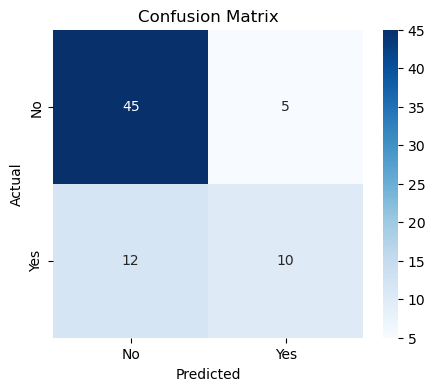

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
# Accuracy, Precision, Recall, F1-Score
print("\nAccuracy:", round(accuracy_score(y_test, y_pred_test), 4))
print("Precision:", round(precision_score(y_test, y_pred_test), 4))
print("Recall:", round(recall_score(y_test, y_pred_test), 4))
print("F1-Score:", round(f1_score(y_test, y_pred_test), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, target_names=['No', 'Yes']))


Accuracy: 0.7639
Precision: 0.6667
Recall: 0.4545
F1-Score: 0.5405

Classification Report:
              precision    recall  f1-score   support

          No       0.79      0.90      0.84        50
         Yes       0.67      0.45      0.54        22

    accuracy                           0.76        72
   macro avg       0.73      0.68      0.69        72
weighted avg       0.75      0.76      0.75        72

